# Transfer Learning for Image Classification ( CIFAR-10 )

## Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, regularizers, initializers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# To confirm GPU is actually available
print("GPUs available:", tf.config.list_physical_devices('GPU'))

# GPU usage confirmation - required by the task
print("GPU device:", tf.test.gpu_device_name())

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
GPU device: /device:GPU:0


I0000 00:00:1789323126.749012      58 gpu_device.cc:2020] Created device /device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789323126.752076      58 gpu_device.cc:2020] Created device /device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [27]:
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

print("Shape:", x_train_full.shape, x_test.shape)
print("Pixel range:", x_train_full.min(), "to", x_train_full.max())
print("Dtype:", x_train_full.dtype)

# CIFAR-10's train/test split (50,000/10,000) is fixed by the dataset's original creators, not something chosen here

Shape: (50000, 32, 32, 3) (10000, 32, 32, 3)
Pixel range: 0 to 255
Dtype: uint8


In [28]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
unique, counts = np.unique(y_train_full, return_counts=True)
print("Class counts:", dict(zip([class_names[i] for i in unique], counts)))

Class counts: {'airplane': np.int64(5000), 'automobile': np.int64(5000), 'bird': np.int64(5000), 'cat': np.int64(5000), 'deer': np.int64(5000), 'dog': np.int64(5000), 'frog': np.int64(5000), 'horse': np.int64(5000), 'ship': np.int64(5000), 'truck': np.int64(5000)}


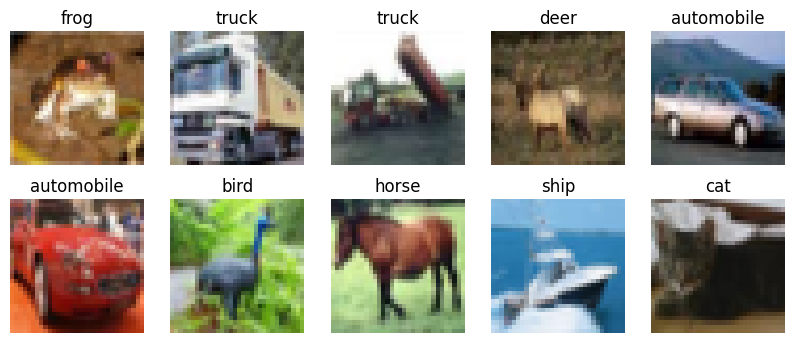

In [29]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train_full[i])
    ax.set_title(class_names[y_train_full[i][0]])
    ax.axis('off')
plt.show()

## Train/Validation Split

In [30]:
# CIFAR-10 provides only train (50,000) and test (10,000) sets. No validation set included. The task requires all three, so validation is carved out of the training set here, leaving the test set completely untouched until final evaluation

# stratify = y_train_full keeps all 10 classes equally represented in both the new train and validation sets, matching the original balanced split

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.1, random_state=42, stratify=y_train_full
)

print("Train:", x_train.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)

Train: (45000, 32, 32, 3)
Validation: (5000, 32, 32, 3)
Test: (10000, 32, 32, 3)


## Preprocessing

In [31]:
IMG_SIZE = 224
BATCH_SIZE = 32

# ImageNet mean/std - the fixed statistics ResNet50 was originally trained on. Using anything else would feed the pretrained layers pixel patterns they were never calibrated for

IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406])
IMAGENET_STD = tf.constant([0.229, 0.224, 0.225])

def preprocess(image, label):
    # Resize from CIFAR-10's native 32x32 up to 224x224, the input size
    # ResNet50 expects
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    image = (image - IMAGENET_MEAN) / IMAGENET_STD
    return image, label

def augment(image, label):
    # Augmentation only ever applies to training data - validation and
    # test sets must reflect real, unaltered images for an honest evaluation
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_crop(tf.image.resize(image, [IMG_SIZE + 20, IMG_SIZE + 20]), [IMG_SIZE, IMG_SIZE, 3])
    image = tf.image.rot90(image, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
    return image, label

# Resizing all 60,000 images to 224×224 and holding them in memory at once would require so many GB's just for storage, risks crashing Colab's RAM
# Solution :  tf.data, it resizes and processes images in small batches on the fly, never holding everything in memory at once.

In [32]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
# Wrap each raw numpy array as a tf.data.Dataset. Batch-by-batch processing instead of resizing all 60,000 images into memory at once

train_ds = train_ds.map(preprocess).map(augment).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
# Preprocess resizes/normalizes every image; Augment only runs on training data, matching the requirement that augmentation must not touch validation/test. shuffle(1000) mixes up the order so the model doesn't see one class in a long unbroken run. batch(BATCH_SIZE) groups images into batches of 32 for training. prefetch lets the CPU prepare the next batch while the GPU is still training on the current one, so the GPU never sits idle waiting for data

# Validation set : Same preprocessing (resize/normalize) but NO augmentation and NO shuffling, since it needs to reflect real, unaltered images for an honest, consistent check each epoch
val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_ds = val_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Test set : Identical treatment to validation, held out until final evaluation
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

for images, labels in train_ds.take(1):
    print("Batch shape:", images.shape, "Label shape:", labels.shape)   # Confirms one real batch actually comes through correctly before training anything

Batch shape: (32, 224, 224, 3) Label shape: (32, 1)


Output Says : 32 images per batch, each resized correctly to 224 × 224 with 3 color channels. Matches RestNet50 (32, 1) : One label per image in the batch.
    
    Why normalization must match ImageNet statistics ?

- ResNet50's weights were learned on millions of ImageNet images that were all normalized using ImageNet's specific mean and std.
- Every internal layer's learned weights are calibrated to expect input in that exact numerical range.
- Feeding it CIFAR-10 images normalized any other way would shift every pixel value outside what those pretrained weights were tuned for.
- The pretrained features would effectively be misapplied to data formatted differently than what it learned from.
    

    Why augmentation improves generalization ?

- Without augmentation, the model only ever sees each training image in one exact form.
- Dog always facing left, cat always cropped the same way.
- It can start memorizing that exact framing rather than learning general dog/cat features.
- Random flips, crops, and rotations show the model many slightly different versions of the same real image, forcing it to learn features that hold up across variation.
- Closer to how it needs to perform on genuinely new images at test time.

## Model Architecture : ResNet50

In [33]:
base_model = ResNet50(weights = 'imagenet', include_top = False, input_shape = (IMG_SIZE, IMG_SIZE, 3))   # Load ResNet50 pretrained on ImageNet, without its original classifier - include_top = False, strips off the final layer that was built for.
# ImageNet's 1000 classes, since we need one built for CIFAR-10's 10

base_model.trainable = False    # Freeze every layer, during feature extraction, only the new classifier head should learn, the pretrained weights stay exactly as ImageNet trained them

print("Total layers in backbone:", len(base_model.layers))
print("Trainable:", base_model.trainable)

Total layers in backbone: 175
Trainable: False


In [34]:
# Classifier Head
x = layers.GlobalAveragePooling2D()(base_model.output)
# GlobalAveragePooling condenses each of ResNet50's output feature maps into a single number per channel. Far fewer parameters than flattening the full feature map, and less prone to overfitting on a small head

x = layers.Dense(512,
                 kernel_initializer = initializers.HeNormal(),
                 kernel_regularizer = regularizers.l2(0.001))(x)

# He initialization is specifically designed for ReLU-activated layers.
# It accounts for the fact that ReLU zeroes out roughly half its inputs, scaling initial weights to prevent signal from shrinking / exploding as it passes through the network

x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
# BatchNormalization stabilizes and speeds up training by normalizing each layer's inputs to a consistent scale, reducing sensitivity to how weights were initialized

x = layers.Dropout(0.5)(x)
# Dropout randomly disables 50% of neurons each training step, forcing the network to not rely too heavily on any single neuron.
# A direct defense against overfitting on top of L2's weight-shrinking effect

outputs = layers.Dense(10)(x)
# Final classification layer, one output per CIFAR-10 class, no activation here since softmax is applied via the loss function during training

model = Model(inputs = base_model.input, outputs = outputs)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,643,978 (94.01 MB)

 Trainable params: 1,055,242 (4.03 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

## Why He initialization is suitable here

- The new classifier head uses ReLU activation, which outputs 0 for any negative input.
- Effectively "turning off" roughly half of a layer's outputs at any time.
- If weights start too small, signal shrinks toward zero as it passes through the network : Too large, and it grows uncontrollably.
- He initialization scales the initial random weights specifically to account for ReLU zeroing out half its inputs, keeping the signal at a stable, consistent scale through the layer from the very first training step.
- Not something a generic (e.g., Xavier/Glorot) initializer accounts for, since that one assumes a different activation function.

## Compile the Model

In [35]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True)
# "from_logits = True" because the final Dense layer has no activation, softmax gets applied internally by the loss function instead, which is more numerically stable than applying softmax manually first

optimizer = AdamW(learning_rate = 1e-3, weight_decay = 1e-4)    # AdamW : Adam with proper weight decay (L2 regularization applied directly to the optimizer step, not mixed into the gradient calculation the way plain Adam + L2 in layers can distort)

model.compile(optimizer = optimizer, loss = loss_fn, metrics = ['accuracy'])

In [36]:
early_stop = EarlyStopping(monitor = 'val_loss', patience = 5, restore_best_weights = True)
# Stops training if val_loss hasn't improved for 5 epochs, prevents wasting time/compute past the point the model stopped genuinely improving, and restores the best-performing weights rather than the final ones

reduce_lr = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.5, patience = 3, min_lr = 1e-6)  # Cuts the learning rate when val_loss plateaus, letting the model take smaller, more precise steps once large steps stop helping

checkpoint = ModelCheckpoint('best_feature_extraction_model.keras', monitor = 'val_loss', save_best_only = True)    # Saves the single best model to disk based on val_loss, independent of whichever epoch training actually stops on

callbacks = [early_stop, reduce_lr, checkpoint]

## Train - Feature Extraction Phase

In [37]:
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 20,
    callbacks = callbacks
)

# Performing minimum 20 epoch, early stopping may end training sooner if val_loss stops improving before then

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 172s 113ms/step - accuracy: 0.3377 - loss: 2.1428 - val_accuracy: 0.3000 - val_loss: 2.1911 - learning_rate: 0.0010
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 150s 105ms/step - accuracy: 0.3847 - loss: 1.8725 - val_accuracy: 0.3268 - val_loss: 2.1160 - learning_rate: 0.0010
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 150s 105ms/step - accuracy: 0.3885 - loss: 1.8446 - val_accuracy: 0.3680 - val_loss: 1.9567 - learning_rate: 0.0010
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 148s 104ms/step - accuracy: 0.3946 - loss: 1.8360 - val_accuracy: 0.3002 - val_loss: 2.1208 - learning_rate: 0.0010
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 148s 104ms/step - accuracy: 0.3944 - loss: 1.8291 - val_accuracy: 0.2940 - val_loss: 2.2555 - learning_rate: 0.0010
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 148s 104ms/step - accuracy: 0.3946 - loss: 1.8322 - val_accuracy: 0.3354 - val_loss: 2.0878 - learning_rate: 0.0010
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 149s 105ms

## From this we can infer :

- Loss went down for both training and validation. The model genuinely learned, no bugs.
- No overfitting either, since train and validation accuracy stayed close.

- Validation accuracy went around a lot in the early epochs, but calmed down once the learning rate dropped.
- The starting rate was likely a bit too high for the new head.

- Final accuracy (47.66%) is lower than usual for this setup, for two clear reasons : CIFAR-10 images are small (32 x 32) and get blurry when stretched to
224 x 224, and training stopped at 20 epochs while it was still improving.

## Training Graph

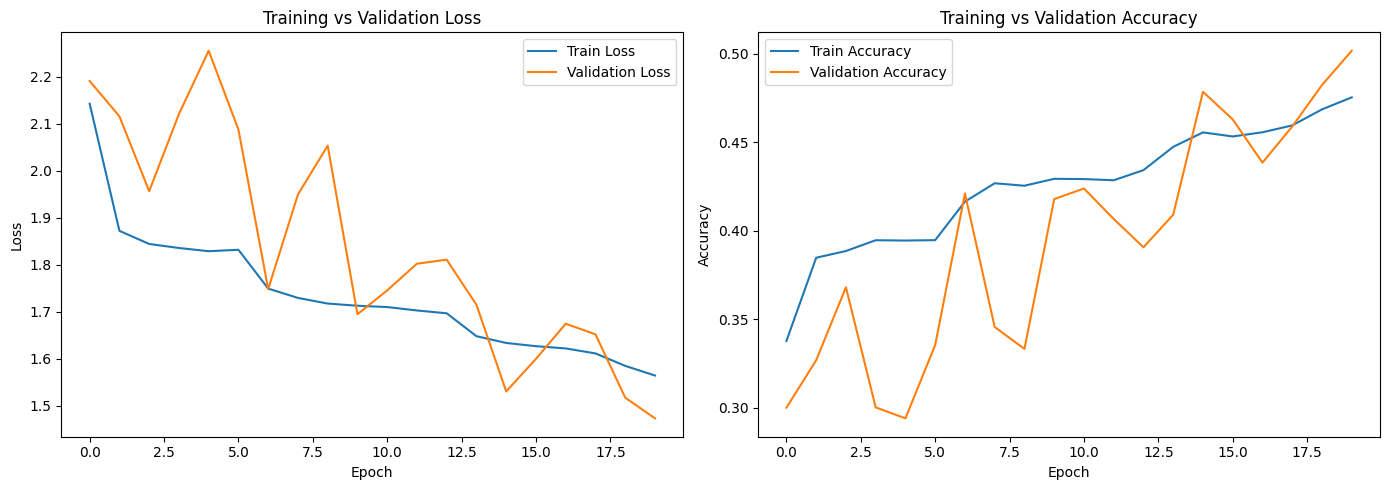

In [38]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

axes[0].plot(history.history['loss'], label = 'Train Loss')
axes[0].plot(history.history['val_loss'], label = 'Validation Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label = 'Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label = 'Validation Accuracy')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## Training Graph Output Analysis

- Train loss and accuracy move smoothly and predictably.
- A clear, steady sign of real learning with no optimization problems.

- Validation loss and accuracy are highly volatile in the first ~9 epochs, then stabilize sharply right after the learning rate first drops (epoch 10).
- Matching ReduceLROnPlateau firing. This points to the initial learning rate being too high for the newly-initialized head, causing large, unstable updates until the rate was reduced.

- By epoch 19, validation loss and accuracy converge closely with training.
- No overfitting, and the volatility resolves rather than persisting.

    Why early stopping in transfer learning ?

- A pretrained backbone already contains strong, general features.
- The new head only needs a modest number of epochs to adapt to those features to the new task before it starts memorizing training-specific noise instead of
learning anything more useful.
- Early stopping catches the exact point validation performance stops improving and halts training there, avoiding
wasted compute and preventing the head from overfitting on top of an already well-formed backbone.

    Why weight decay is important ?

- Weight decay continuously shrinks weights toward zero during training, discouraging the model from relying on a few very large weight values to
fit the training data.
- This is especially relevant here because only the small classifier head is being trained.
- With far fewer parameters and far less data variety than the backbone saw during pretraining, a head with no
weight decay would overfit far more easily.

## Fine-Tuning

In [39]:
for layer in base_model.layers[-20:]:
    layer.trainable = True  # Unfreeze the last 20 layers of the backbone. "last N" as required by the task ; N = 20 is a reasonable starting point to experiment with, not an arbitrary final answer

model.compile(optimizer = AdamW(learning_rate = 1e-5, weight_decay = 1e-4), loss = loss_fn, metrics = ['accuracy'])   # Very small learning rate - fine-tuning needs small adjustments to already-good pretrained weights, not the larger updates used when training a randomly-initialized head from scratch

trainable_count = sum([1 for l in base_model.layers if l.trainable])
print(f"Trainable backbone layers: {trainable_count} of {len(base_model.layers)}")

Trainable backbone layers: 20 of 175


In [40]:
# Fresh EarlyStopping/checkpoint for the fine-tuning phase specifically - comparing against fine-tuning's own best epoch, not carrying over feature-extraction's early-stopping state
early_stop_ft = EarlyStopping(monitor = 'val_loss', patience = 5, restore_best_weights = True)
reduce_lr_ft = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.5, patience = 3, min_lr = 1e-7)
checkpoint_ft = ModelCheckpoint('best_finetuned_model.keras', monitor = 'val_loss', save_best_only = True)

callbacks_ft = [early_stop_ft, reduce_lr_ft, checkpoint_ft]

history_ft = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 20,
    callbacks = callbacks_ft
)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 214s 138ms/step - accuracy: 0.4360 - loss: 1.6870 - val_accuracy: 0.4958 - val_loss: 1.5165 - learning_rate: 1.0000e-05
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 183s 129ms/step - accuracy: 0.4904 - loss: 1.5176 - val_accuracy: 0.5256 - val_loss: 1.4247 - learning_rate: 1.0000e-05
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 182s 128ms/step - accuracy: 0.5112 - loss: 1.4634 - val_accuracy: 0.5462 - val_loss: 1.3677 - learning_rate: 1.0000e-05
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 183s 129ms/step - accuracy: 0.5235 - loss: 1.4271 - val_accuracy: 0.5630 - val_loss: 1.3394 - learning_rate: 1.0000e-05
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 182s 128ms/step - accuracy: 0.5351 - loss: 1.3952 - val_accuracy: 0.5594 - val_loss: 1.3196 - learning_rate: 1.0000e-05
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 182s 128ms/step - accuracy: 0.5464 - loss: 1.3617 - val_accuracy: 0.5696 - val_loss: 1.2955 - learning_rate: 1.0000e-05
Epoch 7/20
1407/1407 ━━━━━━━

## Fine-Tuning Analysis

- Did validation accuracy improve? YES, from 47.66 % to 62.52 %.

- Did overfitting increase? NO, train and validation accuracy stayed close throughout fine-tuning (train 61.38 %, val 62.52 % at epoch 20), and the severe instability seen during feature extraction disappeared.

- Why? Unfreezing the last 20 layers let ResNet50's highest-level features, originally tuned for ImageNet's 1000 real-world object classes, adjust slightly toward CIFAR-10's specific 10 classes.

- The very small learning rate (1e-5) made these adjustments gentle and gradual, improving fit without erasing the pretrained knowledge the model already had (avoid  forgetting).

## Plot & Compare Before & After Fine-Tuning

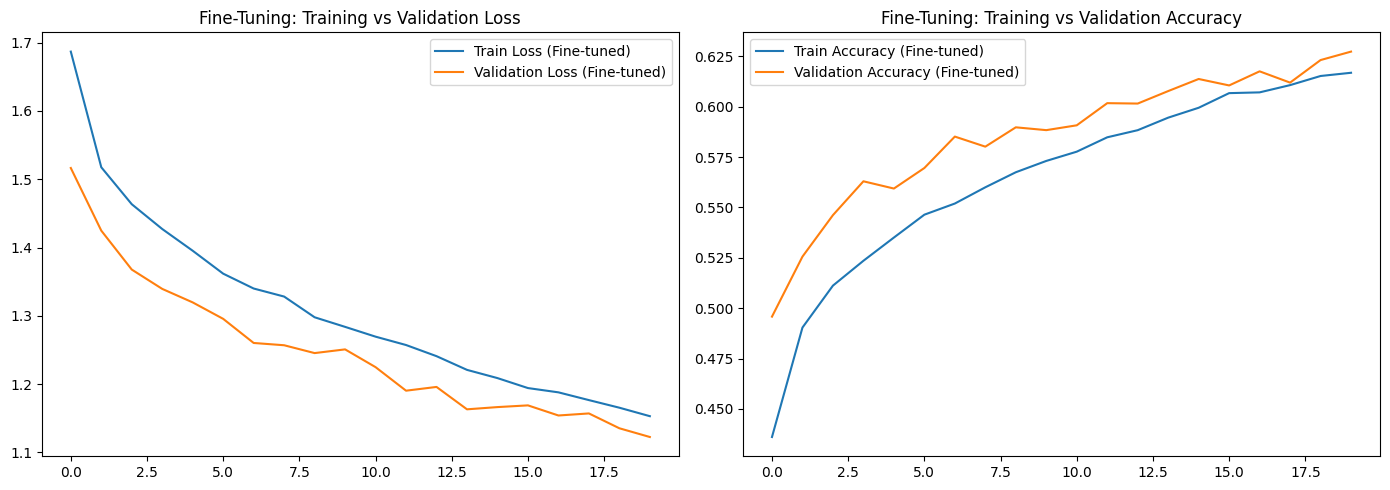

Feature Extraction - Final Val Accuracy:  0.5016
Fine-Tuning       - Final Val Accuracy:  0.6274


In [41]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

axes[0].plot(history_ft.history['loss'], label = 'Train Loss (Fine-tuned)')
axes[0].plot(history_ft.history['val_loss'], label = 'Validation Loss (Fine-tuned)')
axes[0].set_title('Fine-Tuning: Training vs Validation Loss')
axes[0].legend()

axes[1].plot(history_ft.history['accuracy'], label = 'Train Accuracy (Fine-tuned)')
axes[1].plot(history_ft.history['val_accuracy'], label = 'Validation Accuracy (Fine-tuned)')
axes[1].set_title('Fine-Tuning: Training vs Validation Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Feature Extraction - Final Val Accuracy: {history.history['val_accuracy'][-1] : .4f}")
print(f"Fine-Tuning       - Final Val Accuracy: {history_ft.history['val_accuracy'][-1] : .4f}")

## Evaluation

In [42]:
# Predictions on the test set, held out completely until this exact moment
y_pred_logits = model.predict(test_ds)
y_pred = np.argmax(y_pred_logits, axis=1)
y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 110ms/step


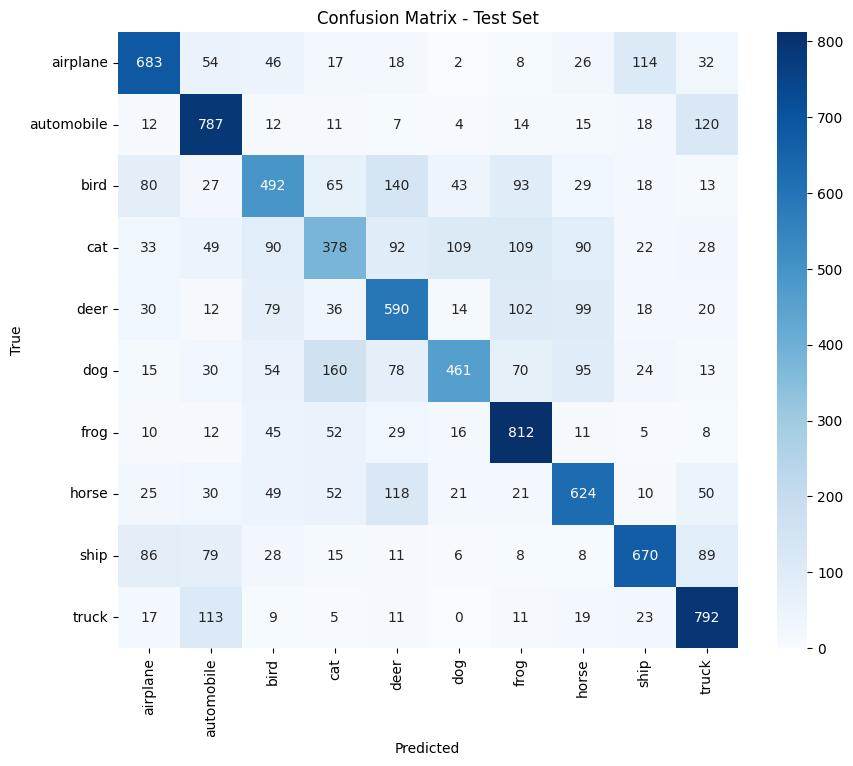

In [43]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Test Set')
plt.show()

In [44]:
# Per-class accuracy, diagonal of the confusion matrix divided by each class's true row total
per_class_acc = cm.diagonal() / cm.sum(axis=1)
for name, acc in zip(class_names, per_class_acc):
    print(f"{name}: {acc:.4f}")

airplane: 0.6830
automobile: 0.7870
bird: 0.4920
cat: 0.3780
deer: 0.5900
dog: 0.4610
frog: 0.8120
horse: 0.6240
ship: 0.6700
truck: 0.7920


In [45]:
# Full classification report, precision, recall, F1 per class
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    airplane       0.69      0.68      0.69      1000
  automobile       0.66      0.79      0.72      1000
        bird       0.54      0.49      0.52      1000
         cat       0.48      0.38      0.42      1000
        deer       0.54      0.59      0.56      1000
         dog       0.68      0.46      0.55      1000
        frog       0.65      0.81      0.72      1000
       horse       0.61      0.62      0.62      1000
        ship       0.73      0.67      0.70      1000
       truck       0.68      0.79      0.73      1000

    accuracy                           0.63     10000
   macro avg       0.63      0.63      0.62     10000
weighted avg       0.63      0.63      0.62     10000



In [46]:
# Hardest classes - lowest per-class accuracy, and what they're most confused with
hardest_idx = np.argsort(per_class_acc)[:3]
print("Hardest classes (lowest accuracy):")
for idx in hardest_idx:
    confused_with = [i for i in np.argsort(cm[idx])[::-1] if i != idx][0]
    print(f"{class_names[idx]}: {per_class_acc[idx]:.4f} accuracy - most confused with {class_names[confused_with]} ({cm[idx][confused_with]} instances)")

Hardest classes (lowest accuracy):
cat: 0.3780 accuracy - most confused with frog (109 instances)
dog: 0.4610 accuracy - most confused with cat (160 instances)
bird: 0.4920 accuracy - most confused with deer (140 instances)


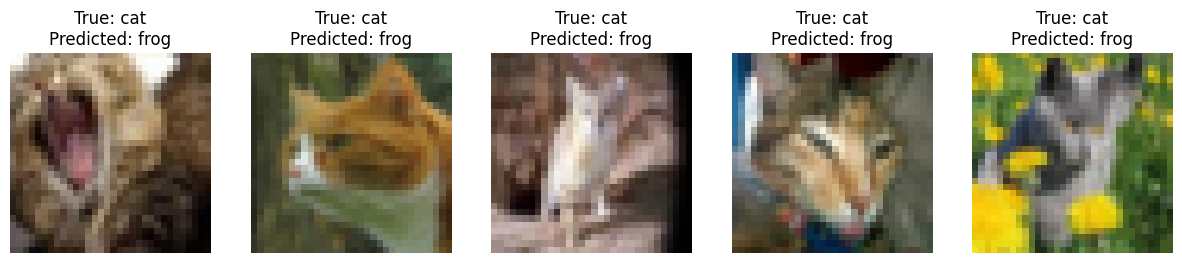

In [48]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, idx in enumerate(misclassified[:5]):
    axes[i].imshow(x_test[idx])
    axes[i].set_title(f'True: cat\nPredicted: frog')
    axes[i].axis('off')
plt.show()